This is to quickly run through the GSV, to identify the dirt section, and then to label the waste section.  

Input: csv from Maoran  
'/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/pano_nairobi.csv'

In [6]:
# pip install torchvision 
# !pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.6/32.6 MB 20.6 MB/s eta 0:00:0000:0100:01


用Try直接跑   /   StreetView? 
需要先装geodanpas再装Detectron2  
PIL PILLOW_VERSION to _version   
torchvision-0.2.2 to torchvision-0.13.0 to ?

# Import

In [1]:
!python -m pip install pyyaml==5.1
# Detectron2 has not released pre-built binaries for the latest pytorch (https://github.com/facebookresearch/detectron2/issues/4053)
# so we install from source instead. This takes a few minutes.
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

# Install pre-built detectron2 that matches pytorch version, if released:
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/{CUDA_VERSION}/{TORCH_VERSION}/index.html

# exit(0)  # After installation, you may need to "restart runtime" in Colab. This line can also restart runtime

  Cloning https://github.com/facebookresearch/detectron2.git to /private/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/pip-req-build-nfulu3n8
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /private/var/folders/2_/nk9j6sb901n_fk5dz_9vtqj80000gn/T/pip-req-build-nfulu3n8
  Resolved https://github.com/facebookresearch/detectron2.git to commit d779ea63faa54fe42b9b4c280365eaafccb280d6
  Preparing metadata (setup.py) ... done


Looking in links: https://dl.fbaipublicfiles.com/detectron2/wheels/{CUDA_VERSION}/{TORCH_VERSION}/index.html


In [1]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

zsh:1: command not found: nvcc
torch:  2.0 ; cuda:  2.0.0
detectron2: 0.6


In [2]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, cv2, json, random
# from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

In [3]:
import os
import glob
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
from shapely.geometry import Point

## Import csv file

In [4]:
# Read from csv (Google Street View / self-collected)
df = pd.read_csv('/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/pano_nairobi.csv')
# df.columns
df

,Unnamed: 0,id,panoid,lat,lon,year,month,marker
0,0,21,khlXWXsuIX7rodKwi1fDAw,-1.347984,36.904885,2021.0,10.0,True
1,1,22,E2SmMwWyLCmPNFOl5-XhxA,-1.286567,36.804547,2021.0,9.0,True
2,2,23,_YVC8LQsymlhhIFp0go_7g,-1.286704,36.804986,2021.0,9.0,True
3,3,24,BOFAYq7l0PF7Lg2_Kn258w,-1.286835,36.805475,2021.0,9.0,True
4,4,25,K3_Pj41onnAOLziZiZeGIw,-1.286968,36.805993,2021.0,9.0,True
...,...,...,...,...,...,...,...,...
126409,126414,213600,f1wVXeQLsTbfDdX1IgZvSg,-1.318228,36.854663,2018.0,1.0,True
126410,126415,213603,U3VouvYaIateSuoSEz6I9Q,-1.318704,36.853164,2021.0,7.0,True
126411,126416,213604,xxfDzMmO__DBRl9my1XA1g,-1.289720,36.812128,2018.0,2.0,True
126412,126417,213605,joG2cf6Yga4GW1DA2UdVcw,-1.289322,36.811855,2021.0,7.0,True


### Add geometry

In [5]:
df['geometry'] = [Point(xy) for xy in zip(df.lon, df.lat)] 

columns = ['Unnamed: 0', 'id', 'lat', 'lon','marker']
df.drop(columns, inplace=True, axis=1)

df = df.reset_index(drop=False)
df.dtypes

index         int64
panoid       object
year        float64
month       float64
geometry     object
dtype: object

In [6]:
gdf = GeoDataFrame(df, crs="EPSG:4326", geometry=df['geometry'])   # geometry: convert object to geometry for gdf
# gdf.dtypes
gdf

,index,panoid,year,month,geometry
0,0,khlXWXsuIX7rodKwi1fDAw,2021.0,10.0,POINT (36.90489 -1.34798)
1,1,E2SmMwWyLCmPNFOl5-XhxA,2021.0,9.0,POINT (36.80455 -1.28657)
2,2,_YVC8LQsymlhhIFp0go_7g,2021.0,9.0,POINT (36.80499 -1.28670)
3,3,BOFAYq7l0PF7Lg2_Kn258w,2021.0,9.0,POINT (36.80547 -1.28684)
4,4,K3_Pj41onnAOLziZiZeGIw,2021.0,9.0,POINT (36.80599 -1.28697)
...,...,...,...,...,...
126409,126409,f1wVXeQLsTbfDdX1IgZvSg,2018.0,1.0,POINT (36.85466 -1.31823)
126410,126410,U3VouvYaIateSuoSEz6I9Q,2021.0,7.0,POINT (36.85316 -1.31870)
126411,126411,xxfDzMmO__DBRl9my1XA1g,2018.0,2.0,POINT (36.81213 -1.28972)
126412,126412,joG2cf6Yga4GW1DA2UdVcw,2021.0,7.0,POINT (36.81186 -1.28932)


In [7]:
# Get All Photo ID and number

AllId = set(gdf.panoid.tolist())
len(AllId)
# AllId

# ？？？？？ Why 113341/126414

113341

### Find path for images

In [8]:
def find_folder(starting_path, target):
    """
    This function attempts to find a folder in the given path that matches the target folder name,
    disregarding the case (upper/lower).
    """
    for folder in os.listdir(starting_path):
        if folder.lower() == target.lower():
            return folder
    return None

def construct_file_path(panoid):
    base_path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/img/'
    # Extract first two characters for folder names
    first_char_folder = find_folder(base_path, panoid[0])
    second_char_folder = find_folder(base_path + first_char_folder + '/', panoid[1])

    if first_char_folder is not None and second_char_folder is not None:
#         file_path = f"{base_path}{first_char_folder}/{second_char_folder}/{panoid}"
        file_path = f"{first_char_folder}/{second_char_folder}/"
        return file_path
    return None


In [9]:
# Assuming df is your DataFrame
gdf['img_path'] = gdf['panoid'].apply(construct_file_path)
gdf

,index,panoid,year,month,geometry,img_path
0,0,khlXWXsuIX7rodKwi1fDAw,2021.0,10.0,POINT (36.90489 -1.34798),K/H/
1,1,E2SmMwWyLCmPNFOl5-XhxA,2021.0,9.0,POINT (36.80455 -1.28657),e/2/
2,2,_YVC8LQsymlhhIFp0go_7g,2021.0,9.0,POINT (36.80499 -1.28670),_/y/
3,3,BOFAYq7l0PF7Lg2_Kn258w,2021.0,9.0,POINT (36.80547 -1.28684),B/O/
4,4,K3_Pj41onnAOLziZiZeGIw,2021.0,9.0,POINT (36.80599 -1.28697),K/3/
...,...,...,...,...,...,...
126409,126409,f1wVXeQLsTbfDdX1IgZvSg,2018.0,1.0,POINT (36.85466 -1.31823),f/1/
126410,126410,U3VouvYaIateSuoSEz6I9Q,2021.0,7.0,POINT (36.85316 -1.31870),U/3/
126411,126411,xxfDzMmO__DBRl9my1XA1g,2018.0,2.0,POINT (36.81213 -1.28972),x/x/
126412,126412,joG2cf6Yga4GW1DA2UdVcw,2021.0,7.0,POINT (36.81186 -1.28932),j/O/


In [21]:
gdf.loc[2]['img_path']

'_/y/'

In [23]:
gdftest = gdf[0:5000]
# gdftest = gdf

gdftest

,index,panoid,year,month,geometry,img_path
0,0,khlXWXsuIX7rodKwi1fDAw,2021.0,10.0,POINT (36.90489 -1.34798),K/H/
1,1,E2SmMwWyLCmPNFOl5-XhxA,2021.0,9.0,POINT (36.80455 -1.28657),e/2/
2,2,_YVC8LQsymlhhIFp0go_7g,2021.0,9.0,POINT (36.80499 -1.28670),_/y/
3,3,BOFAYq7l0PF7Lg2_Kn258w,2021.0,9.0,POINT (36.80547 -1.28684),B/O/
4,4,K3_Pj41onnAOLziZiZeGIw,2021.0,9.0,POINT (36.80599 -1.28697),K/3/
...,...,...,...,...,...,...
4995,4995,-Cpk5DKYIL9taRc7q7eRYw,2018.0,2.0,POINT (36.86575 -1.25570),-/C/
4996,4996,Jbc1xRIg_sIeegCTlL-THQ,2017.0,12.0,POINT (36.86609 -1.25546),j/B/
4997,4997,kG0Pn1Q8mEhb7BCGuOALbQ,2021.0,7.0,POINT (36.86653 -1.25508),K/g/
4998,4998,Z51DlKxTUe_tzPDOmzO9Xw,2017.0,12.0,POINT (36.86667 -1.25466),Z/5/


# Model Setting

In [24]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library

cfg.merge_from_file(model_zoo.get_config_file("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml"))
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml")
cfg.MODEL.DEVICE = 'cpu' #  Game Changer!!!!!!!!!
predictor = DefaultPredictor(cfg)

[01/08 18:16:32 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-PanopticSegmentation/panoptic_fpn_R_101_3x/139514519/model_final_cafdb1.pkl ...


## Segmantation

image - time  
10 pics - 40s  
5,000 pics - 20,000s ~ 6h  
10,000 pics - 40,000s ~ 12h  

In [25]:
import shutil
from IPython.display import Image
from os.path import exists
pd.options.mode.chained_assignment = None  # default = 'warn'

ImgSource = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/img/'
ImgDestin = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/img/4Training/'

LookList = []

import time
from datetime import timedelta
start_time = time.monotonic()

for i, row in gdftest.iterrows():
    print(i)
    id = gdftest.loc[i]['panoid'] # ID for for GSV 

    # Iterate over each heading
    for heading in ['_0', '_90', '_180', '_270']:
        img_name = f"{id}{heading}.jpg"
        img_path = os.path.join(ImgSource + gdftest.loc[i]['img_path'], img_name)  # Construct the full image path

        if exists(img_path):
            im = cv2.imread(img_path)
#             print(img_path)           # print with text
#             Image(filename = img)     # print with image

            outputs = predictor(im)     # Modelling
            OutClass = outputs['panoptic_seg'][1]
        
            image_copied = False  # Flag to check if image has been copied

            # Check for category_id 47 (dirt) and update the corresponding heading column
            for item in OutClass:
                category_id = item.get('category_id')
                area = item.get('area')

                if category_id == 47:
                    column_name = f'Dir{heading}'  # e.g., dir_0, dir_90
                    gdftest.at[i, column_name] = area

                elif category_id == 11:
                    column_name = f'Gra{heading}'  # e.g., gra_0, gra_90
                    gdftest.at[i, column_name] = area

                # Copy the image if it matches either category and has not been copied yet
                if category_id in [47, 11] and not image_copied:
                    destination_path = os.path.join(ImgDestin, img_name)
                    shutil.copy(img_path, destination_path)
                    image_copied = True
end_time = time.monotonic()
print(timedelta(seconds = end_time - start_time))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1861
1862
1863
1864
1865
1866
1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060


KeyboardInterrupt: 

In [20]:
# gdftest.head
gdftest

,index,panoid,year,month,geometry,img_path,Dir_90,Dir_270,Gra_90,Dir_0,Dir_180
0,0,khlXWXsuIX7rodKwi1fDAw,2021.0,10.0,POINT (36.90489 -1.34798),K/H/,6537.0,8159.0,NaN,NaN,NaN
1,1,E2SmMwWyLCmPNFOl5-XhxA,2021.0,9.0,POINT (36.80455 -1.28657),e/2/,NaN,NaN,NaN,NaN,NaN
2,2,_YVC8LQsymlhhIFp0go_7g,2021.0,9.0,POINT (36.80499 -1.28670),_/y/,NaN,NaN,NaN,15659.0,NaN
3,3,BOFAYq7l0PF7Lg2_Kn258w,2021.0,9.0,POINT (36.80547 -1.28684),B/O/,NaN,NaN,NaN,NaN,NaN
4,4,K3_Pj41onnAOLziZiZeGIw,2021.0,9.0,POINT (36.80599 -1.28697),K/3/,NaN,NaN,NaN,4697.0,NaN
5,5,R03__WaTl8b6-eJvAITjxg,2021.0,9.0,POINT (36.80645 -1.28708),r/0/,NaN,NaN,NaN,NaN,21571.0
6,6,_YgkrW4dWtUjeWh-q5Eg9Q,2017.0,12.0,POINT (36.80702 -1.28720),_/y/,NaN,NaN,NaN,NaN,NaN
7,7,pyICOaeiV6GRoisgvRazCQ,2017.0,12.0,POINT (36.80736 -1.28730),P/y/,NaN,NaN,NaN,NaN,NaN
8,8,7XjEVopQENObR-NK9TdWXg,2017.0,12.0,POINT (36.80791 -1.28744),7/x/,NaN,NaN,NaN,NaN,NaN
9,9,4XiMLjpoNf3hzJP9sG__Hw,2021.0,9.0,POINT (36.80838 -1.28757),4/x/,NaN,NaN,NaN,NaN,NaN


In [13]:
# If only want to check one category

import shutil
from IPython.display import Image
from os.path import exists
pd.options.mode.chained_assignment = None  # default = 'warn'

ImgSource = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/img/'
ImgDestin = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/img/4Training/'

LookList = []

import time
from datetime import timedelta
start_time = time.monotonic()

for i, row in gdftest.iterrows():

    id = gdftest.loc[i]['panoid'] # ID for for GSV 

    # Iterate over each heading
    for heading in ['_0', '_90', '_180', '_270']:
        img_name = f"{id}{heading}.jpg"
        img_path = os.path.join(ImgSource + gdftest.loc[i]['img_path'], img_name)  # Construct the full image path

        if exists(img_path):
            im = cv2.imread(img_path)
#             print(img_path)           # print with text
#             Image(filename = img)     # print with image

            outputs = predictor(im)     # Modelling
            OutClass = outputs['panoptic_seg'][1]
        
            # Check for category_id 47 (dirt) and update the corresponding heading column
            for item in OutClass:
                if item.get('category_id') == 47:
                    gdftest.at[i, f'Dir{heading}'] = item.get('area')
                    
                    # Copy the image to ImgDestin
                    destination_path = os.path.join(ImgDestin, img_name)
                    shutil.copy(img_path, destination_path)
                    
                    break  # No need to check further once category_id 47 is found
    
end_time = time.monotonic()
print(timedelta(seconds = end_time - start_time))

/opt/miniconda3/envs/StreetView/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


0:00:44.523026


# Export

In [42]:
gdftest.to_csv('/Users/wenlanzhang/Downloads/PhD_UCL/Data/GoogleStreetView/Maoran/GSVI_PreScreen.csv', index = False)

# Below are test

In [22]:
outputs['panoptic_seg'][1]

[{'id': 1,
  'isthing': True,
  'score': 0.5915431976318359,
  'category_id': 2,
  'instance_id': 0},
 {'id': 2, 'isthing': False, 'category_id': 21, 'area': 14933},
 {'id': 3, 'isthing': False, 'category_id': 37, 'area': 1538449},
 {'id': 4, 'isthing': False, 'category_id': 38, 'area': 46620},
 {'id': 5, 'isthing': False, 'category_id': 40, 'area': 21440},
 {'id': 6, 'isthing': False, 'category_id': 44, 'area': 26464},
 {'id': 7, 'isthing': False, 'category_id': 46, 'area': 4321},
 {'id': 8, 'isthing': False, 'category_id': 47, 'area': 66832},
 {'id': 9, 'isthing': False, 'category_id': 50, 'area': 18329},
 {'id': 10, 'isthing': False, 'category_id': 52, 'area': 17445}]

In [23]:
gdftest

,captured_at,compass_angle,id,sequence_id,tile_x,tile_y,tile_z,geometry
0,1502959750000,0.000000,896597831196632,uyM5gJjQSAM7eKfObh4qKQ,9873,8249,14,POINT (36.94763 -1.26758)
1,1502966894000,71.876938,555315025832458,H6fRjtsMmuHb3I06YYpgQQ,9873,8249,14,POINT (36.95400 -1.25815)
2,1502961468000,166.631247,315127656718481,70accd7gmkd8nrl6vj5tmy,9873,8249,14,POINT (36.95140 -1.26740)
3,1502960027000,159.407698,341403537326675,c4nvikpmgpskhdlgcotmr6,9873,8249,14,POINT (36.93909 -1.27072)
4,1502966783000,74.162760,732275437451275,H6fRjtsMmuHb3I06YYpgQQ,9873,8249,14,POINT (36.95164 -1.25771)
...,...,...,...,...,...,...,...,...
87293,1512656296731,56.721008,742174863117205,09FJzEEMPqUwbzUA8dBQ-w,9873,8250,14,POINT (36.94765 -1.29050)
87294,1512479011402,61.818970,1182016202274042,yt3zlyuqreedwjap6lgjdg,9873,8250,14,POINT (36.94950 -1.28938)
87295,1512479083398,56.229614,492008345991699,jrjR73FdOXq6br5aCr-njQ_v00,9873,8250,14,POINT (36.95371 -1.28672)
87296,1512478951402,55.323608,1178023463024401,jrjR73FdOXq6br5aCr-njQ_v00,9873,8250,14,POINT (36.94575 -1.29170)


In [15]:
len(LookList)

4725

## Image import

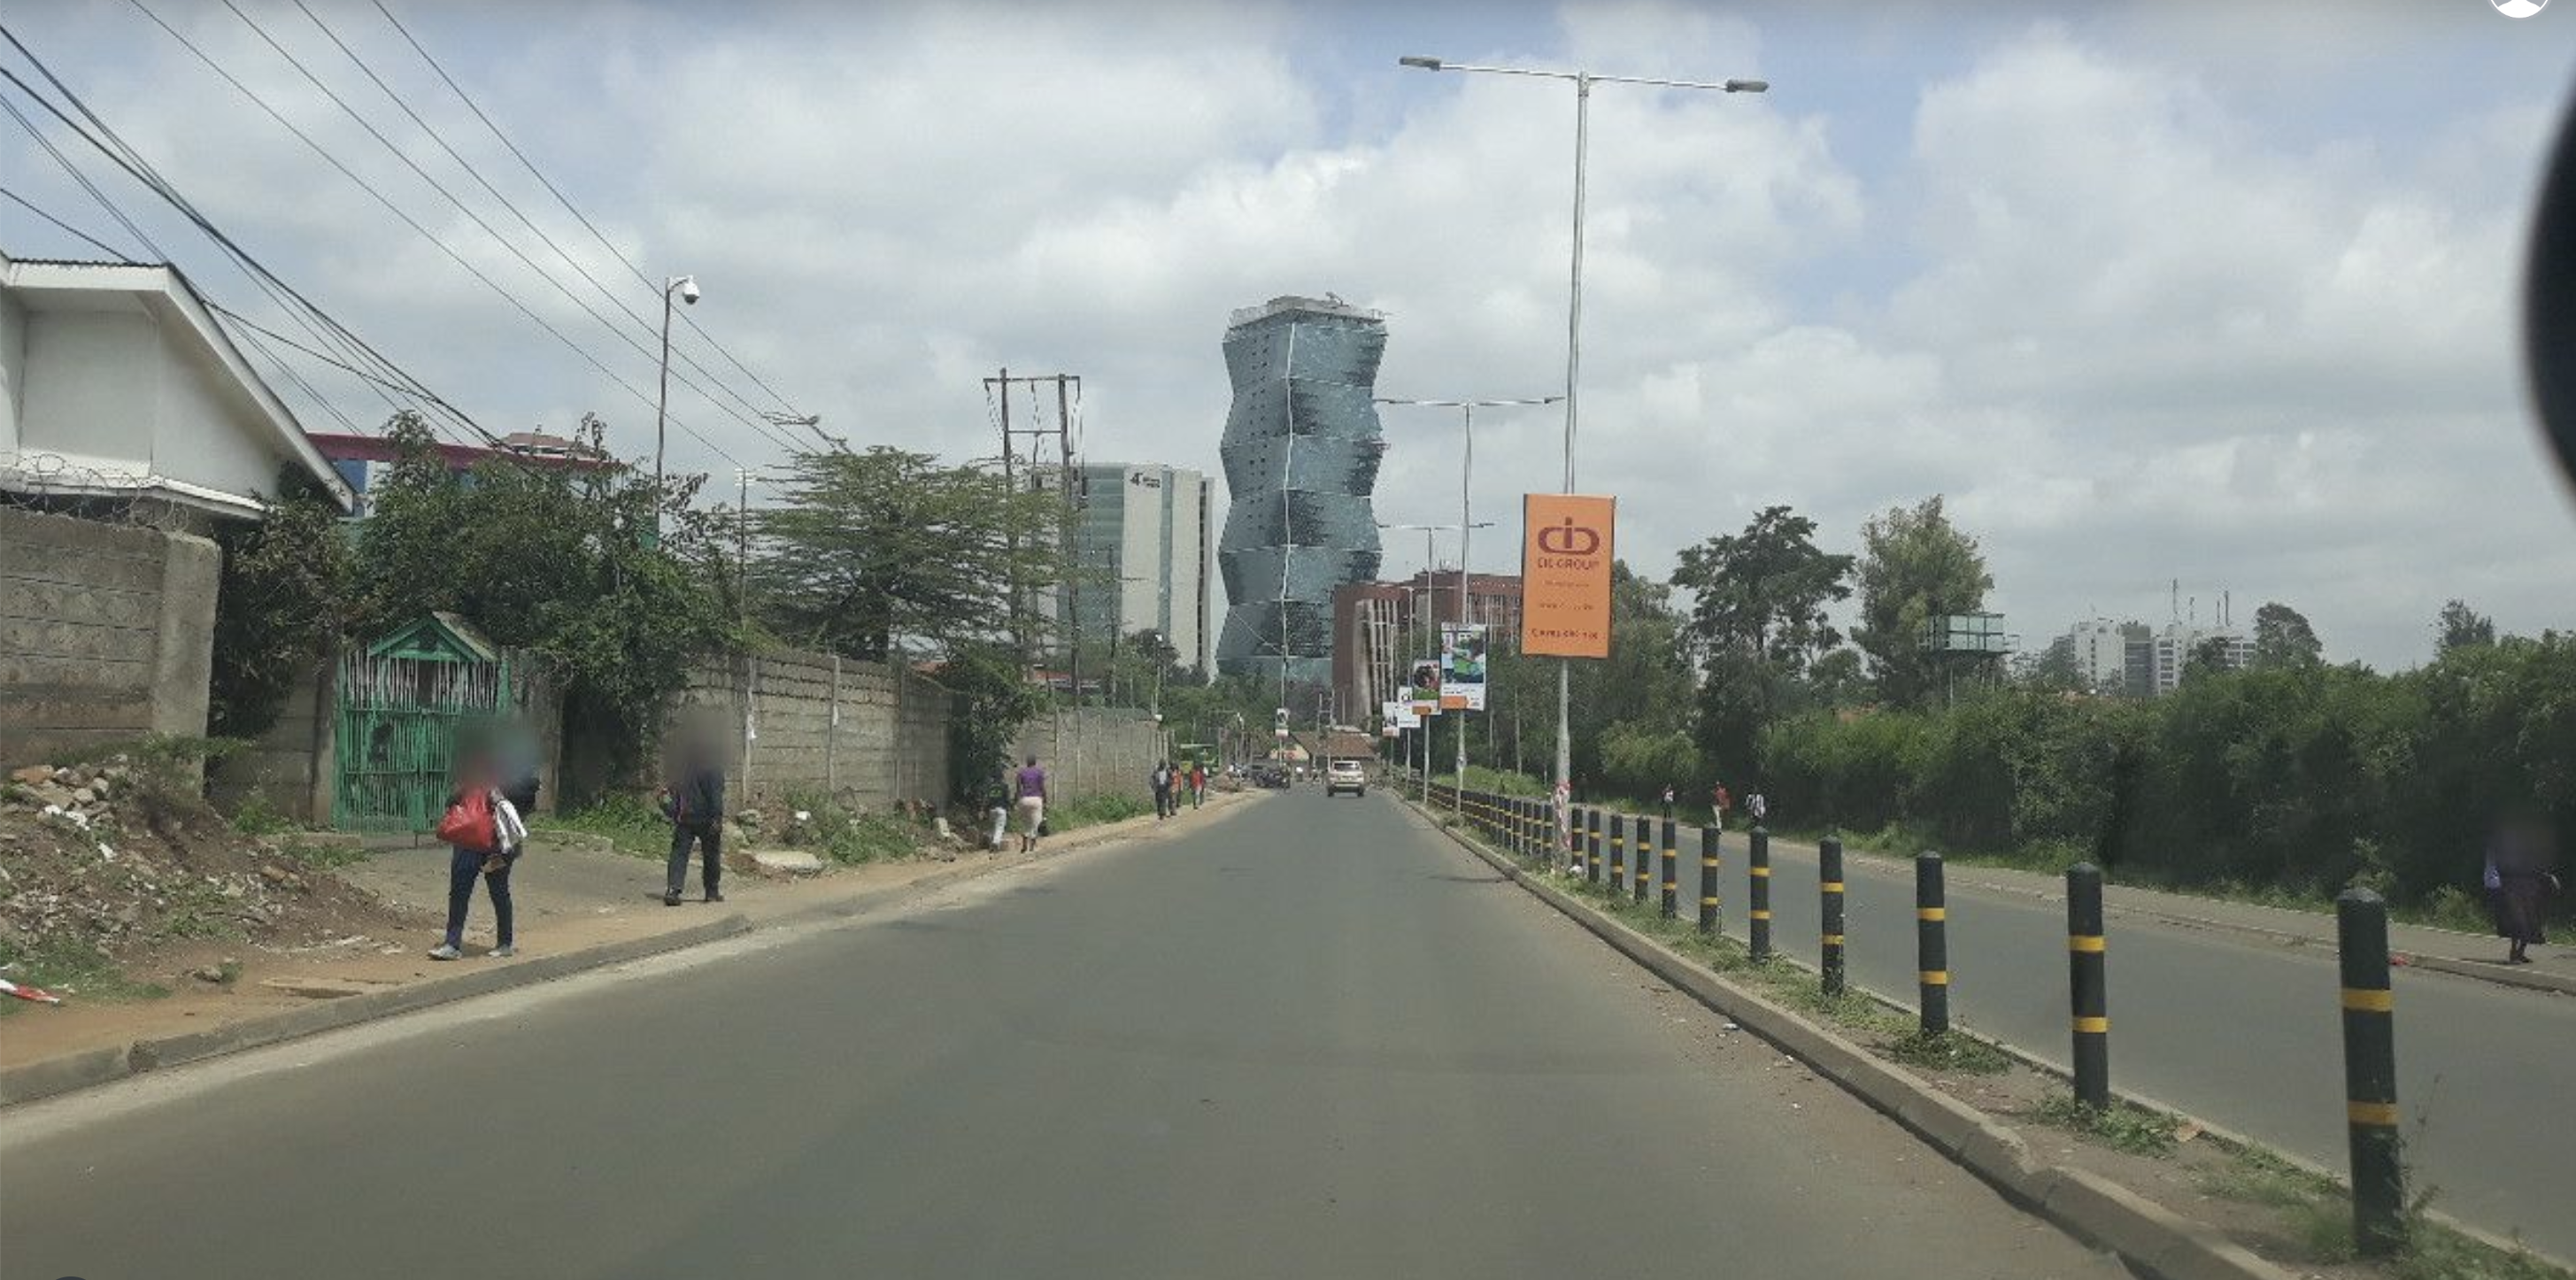

In [4]:
from IPython.display import Image

# img = '/Users/wenlanzhang/Downloads/WechatIMG58.png'
img = '/Users/wenlanzhang/Downloads/WechatIMG57.png'
im = cv2.imread(img)
Image(filename = img) 

In [6]:
im.shape

(1446, 2910, 3)

In [5]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library

cfg.merge_from_file(model_zoo.get_config_file("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml"))
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-PanopticSegmentation/panoptic_fpn_R_101_3x.yaml")
cfg.MODEL.DEVICE = 'cpu' #  Game Changer!!!!!!!!!
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

/opt/miniconda3/envs/Try/lib/python3.10/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1659484612588/work/aten/src/ATen/native/TensorShape.cpp:2895.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Get Output (Practice?)

In [8]:
# https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)

tensor([14,  2, 33,  1])
Boxes(tensor([[1102.8564,  528.7402, 1474.2327,  638.1035],
        [  49.6595,  867.6553, 2047.0000, 1125.7849],
        [1093.8314,  527.2991, 1440.6884,  659.0178],
        [  72.1595,  861.0406, 2023.1965, 1121.7094]]))


In [9]:
instances = outputs["instances"]
detected_class_indexes = instances.pred_classes
prediction_boxes = instances.pred_boxes
metadata = MetadataCatalog.get(cfg.DATASETS.TRAIN[0])
class_catalog = metadata.thing_classes

for idx, coordinates in enumerate(prediction_boxes):
    class_index = detected_class_indexes[idx]
    class_name = class_catalog[class_index]
    print(class_name, coordinates)
    
# https://stackoverflow.com/questions/67516185/in-detectron-2-how-could-i-get-detected-object-class-name-and-the-bounding-box-x

bird tensor([1102.8564,  528.7402, 1474.2327,  638.1035])
car tensor([  49.6595,  867.6553, 2047.0000, 1125.7849])
kite tensor([1093.8314,  527.2991, 1440.6884,  659.0178])
bicycle tensor([  72.1595,  861.0406, 2023.1965, 1121.7094])


### Get Text

In [10]:
OutClass = outputs['panoptic_seg'][1]
ListID = []
ListClass = []
for element in OutClass:
    print(element)
#     print(type(element))
    ID = element['id']
    CategoryId = element['category_id']
    ListID.append(ID)
    ListClass.append(CategoryId)

{'id': 1, 'isthing': False, 'category_id': 12, 'area': 31493}
{'id': 2, 'isthing': False, 'category_id': 37, 'area': 1082978}
{'id': 3, 'isthing': False, 'category_id': 40, 'area': 189139}
{'id': 4, 'isthing': False, 'category_id': 44, 'area': 9825}
{'id': 5, 'isthing': False, 'category_id': 46, 'area': 164068}
{'id': 6, 'isthing': False, 'category_id': 47, 'area': 51815}


In [11]:
ListClass

[12, 37, 40, 44, 46, 47]

In [45]:
outputs["instances"]

Instances(num_instances=4, image_height=1152, image_width=2047, fields=[pred_boxes: Boxes(tensor([[1112.7338,  530.3188, 1522.9890,  634.3343],
        [  48.9987,  867.8086, 2047.0000, 1125.9659],
        [1093.5472,  527.2275, 1441.2021,  659.4970],
        [  72.3716,  861.2883, 2023.8302, 1122.1166]])), scores: tensor([0.2719, 0.1992, 0.0622, 0.0577]), pred_classes: tensor([14,  2, 33,  1]), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, Fals

In [43]:
type(outputs['panoptic_seg'])

tuple

In [14]:
outputs

{'sem_seg': tensor([[[ 2.2776,  2.2776,  2.2769,  ...,  2.1866,  2.0868,  2.0137],
          [ 2.2776,  2.2776,  2.2769,  ...,  2.1866,  2.0868,  2.0137],
          [ 2.2870,  2.2870,  2.2867,  ...,  2.2133,  2.1136,  2.0407],
          ...,
          [ 5.5977,  5.5977,  5.6083,  ...,  4.6261,  4.5207,  4.4435],
          [ 5.5467,  5.5467,  5.5569,  ...,  4.5891,  4.4901,  4.4176],
          [ 5.5093,  5.5093,  5.5193,  ...,  4.5620,  4.4677,  4.3987]],
 
         [[-0.2955, -0.2955, -0.2963,  ..., -0.3640, -0.3410, -0.3242],
          [-0.2955, -0.2955, -0.2963,  ..., -0.3640, -0.3410, -0.3242],
          [-0.2953, -0.2953, -0.2962,  ..., -0.3636, -0.3404, -0.3233],
          ...,
          [-1.3913, -1.3913, -1.3933,  ..., -1.2165, -1.1680, -1.1325],
          [-1.3457, -1.3457, -1.3476,  ..., -1.1756, -1.1304, -1.0972],
          [-1.3123, -1.3123, -1.3141,  ..., -1.1457, -1.1028, -1.0714]],
 
         [[-2.4236, -2.4236, -2.4259,  ..., -2.1317, -2.1175, -2.1071],
          [-2.423

explaination:
    https://towardsdatascience.com/understanding-detectron2-demo-bc648ea569e5

### Get Image

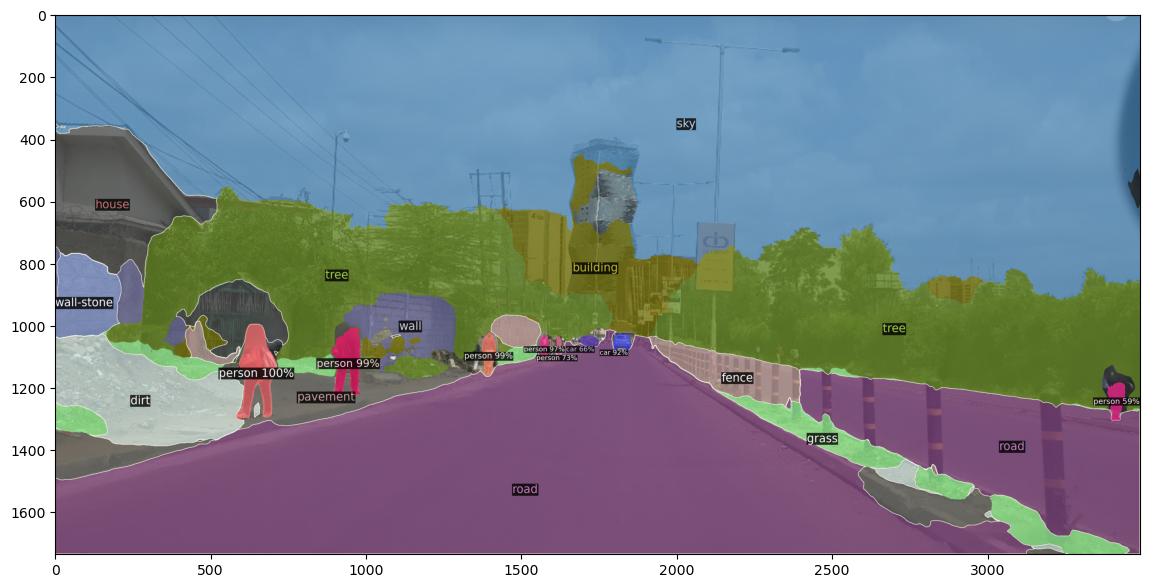

In [7]:
# Show img
import matplotlib.pyplot as plt

panoptic_seg, segments_info = predictor(im)["panoptic_seg"]
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
v = v.draw_panoptic_seg_predictions(panoptic_seg.to("cpu"), segments_info)

plt.figure(figsize=(14,10))
plt.imshow(v.get_image())
plt.show()

# 
# https://stackoverflow.com/questions/71717980/in-detectron2-there-are-class-ids-instead-of-class-names

In [ ]:
# Show img in a new window

panoptic_seg, segments_info = predictor(im)["panoptic_seg"]
v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_panoptic_seg_predictions(panoptic_seg.to("cpu"), segments_info)
cv2.imshow('Result', out.get_image()[:, :, ::-1])
cv2.waitKey(0)